# Losses per Position — CP16/EP16 @ 32k, 3-doc packed row (no repro)

Minimization step 3: golden cp16/ep16 leaf at `max_seq_len=32768`, with **3 docs of ~10k each**
packed into a single row — restoring multi-doc partition-tail structure at the smallest scale.

**Result: NO repro.** 3/3 window reps clean. No rep0-outlier destruction.

## Data

| datum | kind | tokens | supervised | description |
|---|---|---|---|---|
| 0 | palindrome | 9,999 | all | `ABCDEFEDCBA` repeated — saturated logits, ~0 churn |
| 1 | random-tile | 9,999 | all | 256-token random chunk (seed 1003200) tiled to 10k |
| 2 | mudith-b0-i0-first10k | 9,999 | all | first 10k tokens of Mudith's doc 0 (orig 41,381 tokens) |

All positions supervised (uniform weights, no prefix masking) — per Jack's directive after
the min32k single-doc run revealed that masked-payload dumps only measure supervised bands.

## Key findings

- **Datum 2 (mudith) has high NLL (~2.7)** but it's consistent across all reps — NOT the rep0
  destruction signature (that would be an asymmetric +5-11 nat MEAN shift on rep0 only, healing by rep1).
- **Real-text docs have large ambient per-token churn**: 12-18% of positions differ by >1 nat between
  identical no-optim forwards (max 15-19 nats on individual uncertain tokens). This is the noise floor.
- **Synthetic docs barely churn** (palindrome 0, random-tile ≤3 positions) because their logits are saturated.
- **Position and packing exonerated** for the high-NLL effect: control probes (`mud_first` = mudith
  as row head, `mud_solo` = mudith alone) show the same NLL regardless of packing position or multi-doc context.

Run: `min32k/x3x10k_0801_011540/` (main 3x10k reps + control probes).
Config: `trainer-config.cp16s32k.json` (tp1/pp1/ep16/cp16, dp1, flash, lora32, max_seq_len 32768).


In [1]:
import gzip, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path('../../../min32k/x3x10k_0801_011540')
if not RUN_DIR.exists():
    for cand in [Path('../../../experiment_artefacts/glm/lps1003_loss_spikes/min32k/x3x10k_0801_011540'),
                 Path('../../experiment_artefacts/glm/lps1003_loss_spikes/min32k/x3x10k_0801_011540')]:
        if cand.exists():
            RUN_DIR = cand
            break
RUN_DIR = RUN_DIR.resolve()

N_REPS = 3
DATUM_LABELS = ['palindrome', 'random-tile', 'mudith-b0-i0-first10k']

reps = {}
for r in range(N_REPS):
    p = RUN_DIR / f'min32k_3x10k_rep{r}.json.gz'
    reps[r] = json.load(gzip.open(p))
    print(f"rep{r}: nlls={[f'{x:.6f}' for x in reps[r]['nlls']]}  destroyed={reps[r]['destroyed']}")

rep0: nlls=['0.003131', '0.358681', '2.686448']  destroyed={'2': 2.686}
rep1: nlls=['0.003073', '0.356713', '2.724344']  destroyed={'2': 2.724}
rep2: nlls=['0.003089', '0.355388', '2.701677']  destroyed={'2': 2.702}


### Plot 1 — Per-position NLL: rep0 vs rep1 (all 3 datums)

Each datum is 9,999 positions, all supervised. The three datums are packed into one 32k row
(datum 0 at the head, datum 2 at the tail = the partition-tail danger zone).
Note the very different y-axis scales: palindrome NLL is near 0, random-tile ~0.36,
and mudith ~2.7 (real English text is harder to predict than synthetic patterns).


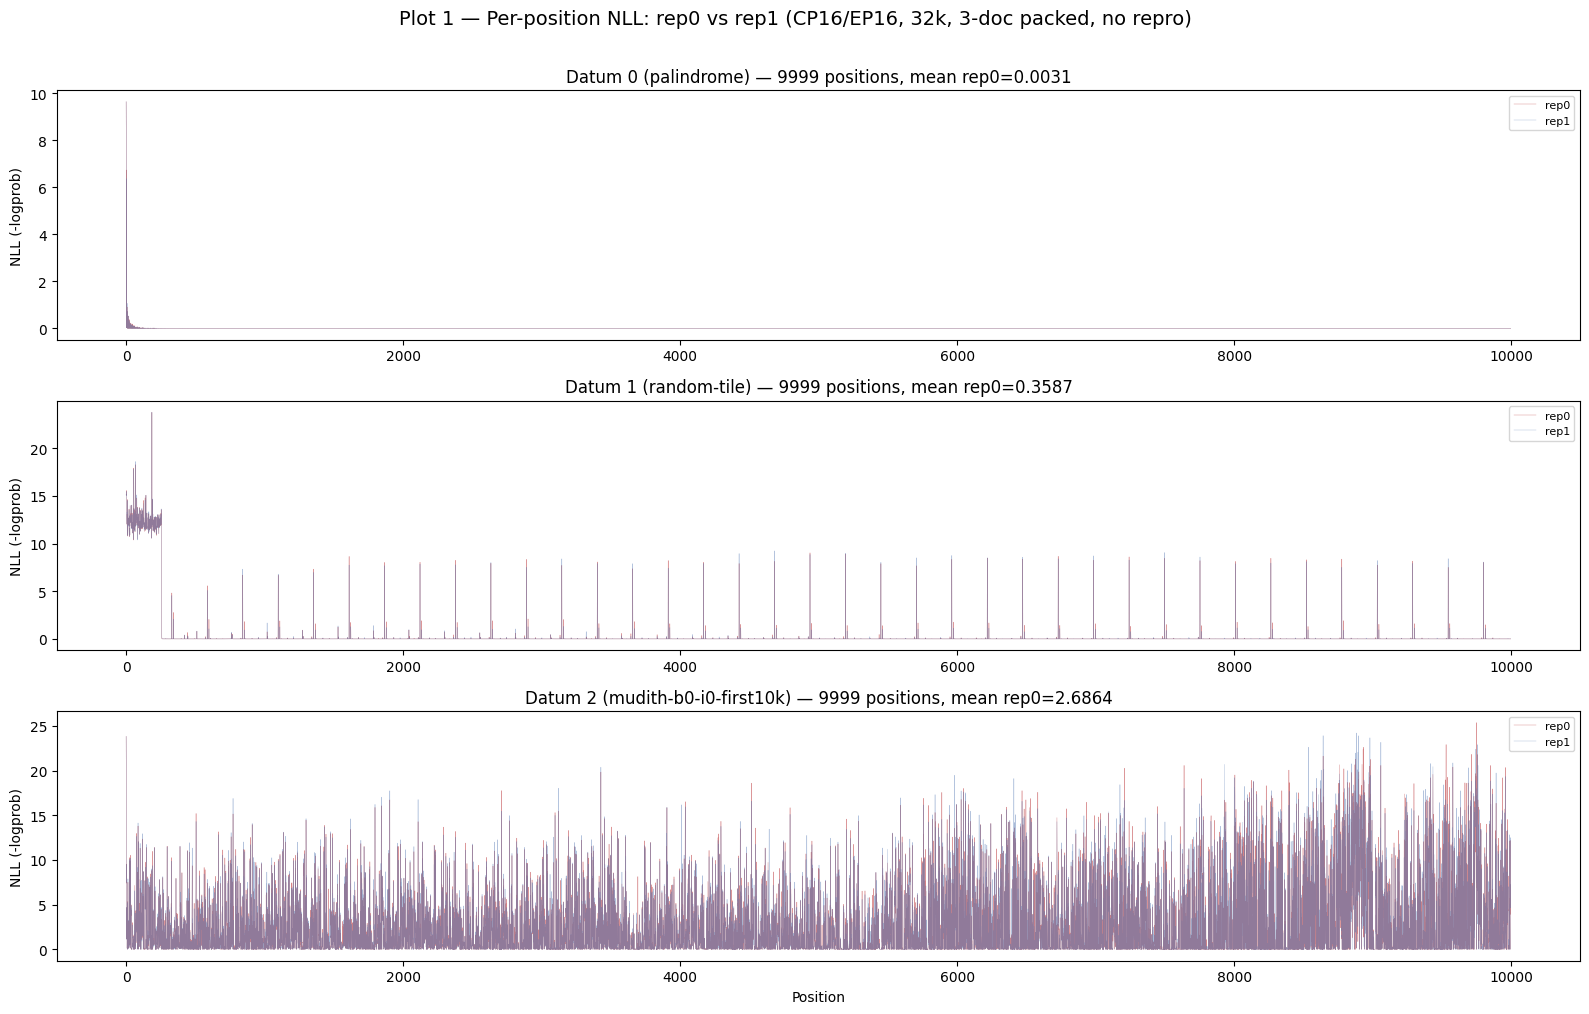

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for di, ax in enumerate(axes):
    nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
    x = np.arange(len(nll0))

    ax.plot(x, nll0, color='#C44E52', linewidth=0.3, alpha=0.7, label='rep0')
    ax.plot(x, nll1, color='#4C72B0', linewidth=0.3, alpha=0.5, label='rep1')

    ax.set_ylabel('NLL (-logprob)')
    ax.set_title(f'Datum {di} ({DATUM_LABELS[di]}) — {len(nll0)} positions, mean rep0={nll0.mean():.4f}')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position')
fig.suptitle('Plot 1 — Per-position NLL: rep0 vs rep1 (CP16/EP16, 32k, 3-doc packed, no repro)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Plot 2 — Per-rep NLL (bar chart)

Left: per-datum NLL by rep (log scale — palindrome is ~1000x smaller than mudith).
Right: total NLL per rep. All reps are within ±0.04 nats — no rep0 outlier.


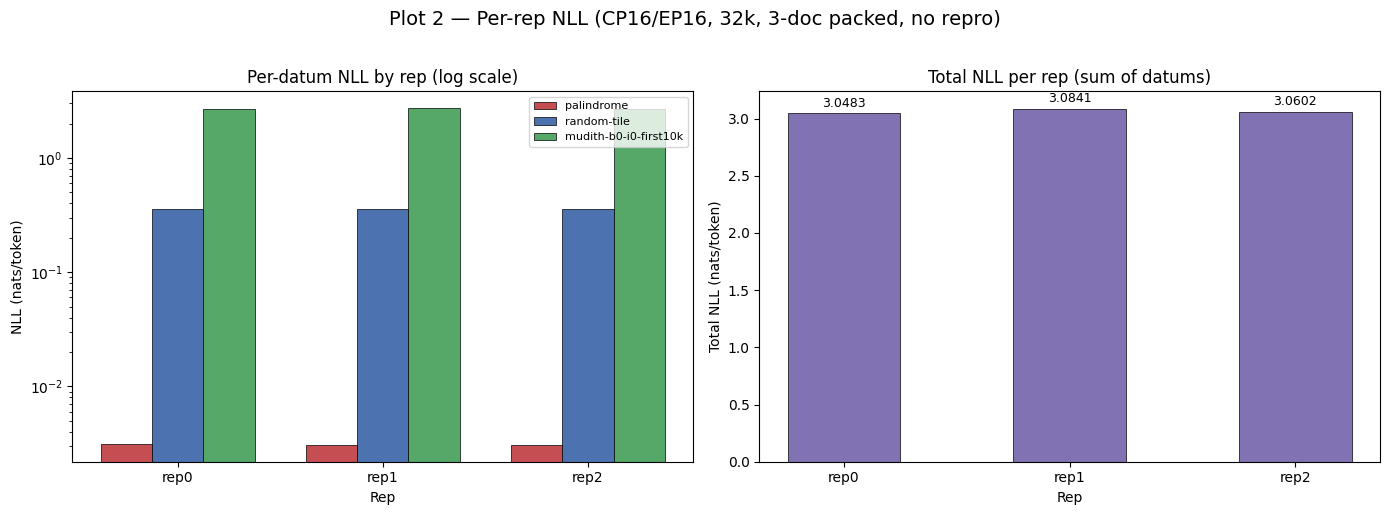

In [3]:
n_datums = len(reps[0]['nlls'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-datum NLL per rep (log scale)
x = np.arange(N_REPS)
width = 0.25
colors = ['#C44E52', '#4C72B0', '#55A868']
for di in range(n_datums):
    vals = [reps[r]['nlls'][di] for r in range(N_REPS)]
    offset = (di - n_datums/2 + 0.5) * width
    ax1.bar(x + offset, vals, width, label=DATUM_LABELS[di],
            color=colors[di], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Rep')
ax1.set_ylabel('NLL (nats/token)')
ax1.set_title('Per-datum NLL by rep (log scale)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'rep{r}' for r in range(N_REPS)])
ax1.set_yscale('log')
ax1.legend(fontsize=8)

# Right: total NLL per rep
totals = [sum(reps[r]['nlls']) for r in range(N_REPS)]
bars = ax2.bar(x, totals, width=0.5, color='#8172B3', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Rep')
ax2.set_ylabel('Total NLL (nats/token)')
ax2.set_title('Total NLL per rep (sum of datums)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'rep{r}' for r in range(N_REPS)])
for bar, val in zip(bars, totals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Plot 2 — Per-rep NLL (CP16/EP16, 32k, 3-doc packed, no repro)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (all 3 datums)

The 1-nat threshold line marks the noise floor boundary. Real-text datum (mudith) shows
substantial per-token churn — ~12-18% of positions exceed 1 nat — but this is **ambient
nondeterminism** (symmetric across all rep pairs, not rep0-specific). Synthetic datums
(palindrome, random-tile) barely churn because their logits are saturated.


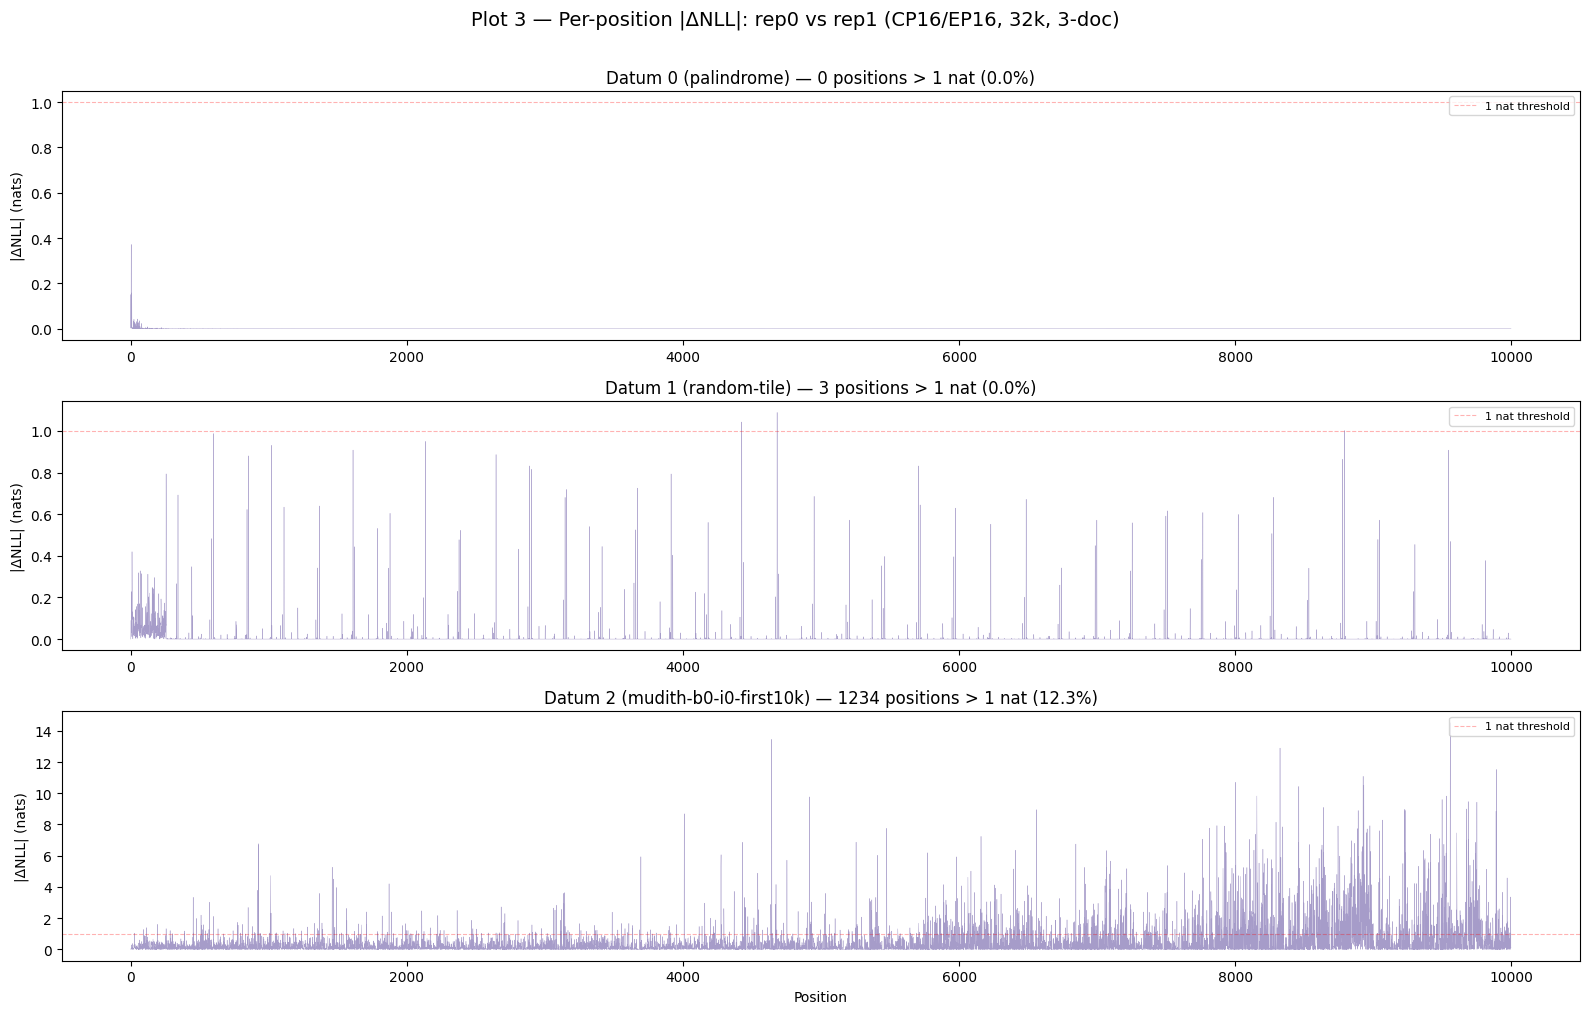

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for di, ax in enumerate(axes):
    nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
    delta = np.abs(nll0 - nll1)
    x = np.arange(len(delta))

    ax.plot(x, delta, color='#8172B3', linewidth=0.3, alpha=0.7)
    ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')

    n_big = int((delta > 1.0).sum())
    pct = n_big / len(delta) * 100
    ax.set_ylabel('|ΔNLL| (nats)')
    ax.set_title(f'Datum {di} ({DATUM_LABELS[di]}) — {n_big} positions > 1 nat ({pct:.1f}%)')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position')
fig.suptitle('Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (CP16/EP16, 32k, 3-doc)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Plot 3 zoom — mudith-b0-i0-first10k (datum 2), positions 0..500

Zoom into the first 500 positions of the real-text datum to see the per-token churn structure.
Individual uncertain tokens spike to 15-19 nats of |ΔNLL| between reps — this is the ambient
noise floor from near-tie logits reshuffling selected KV sets, not the destruction signature.


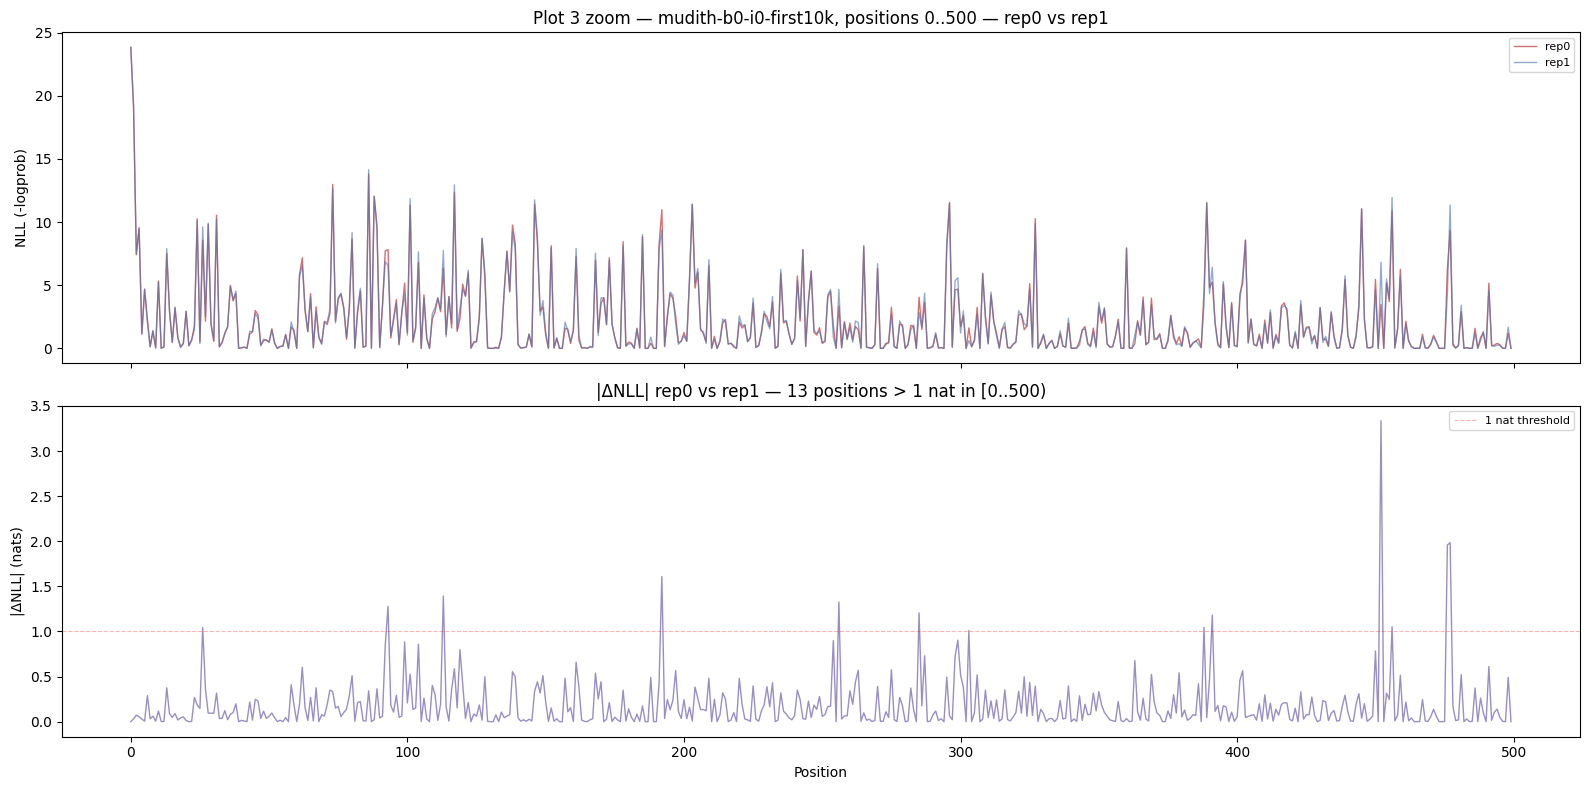

In [5]:
di = 2  # mudith
ZOOM_END = 500

nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
delta = np.abs(nll0 - nll1)
x = np.arange(len(delta))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: per-position NLL for rep0 and rep1
ax = axes[0]
ax.plot(x[:ZOOM_END], nll0[:ZOOM_END], color='#C44E52', linewidth=1.0, alpha=0.8, label='rep0')
ax.plot(x[:ZOOM_END], nll1[:ZOOM_END], color='#4C72B0', linewidth=1.0, alpha=0.6, label='rep1')
ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'Plot 3 zoom — {DATUM_LABELS[di]}, positions 0..{ZOOM_END} — rep0 vs rep1')
ax.legend(loc='upper right', fontsize=8)

# Bottom: |ΔNLL|
ax = axes[1]
ax.plot(x[:ZOOM_END], delta[:ZOOM_END], color='#8172B3', linewidth=1.0, alpha=0.8)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
n_big = int((delta[:ZOOM_END] > 1.0).sum())
ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Position')
ax.set_title(f'|ΔNLL| rep0 vs rep1 — {n_big} positions > 1 nat in [0..{ZOOM_END})')
ax.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

### Control probes — position & packing exonerated

Three control probes from the same run confirm the high-NLL on mudith data is NOT the bug:

| probe | payload | mudith NLL (rep0) | interpretation |
|---|---|---|---|
| `mud_first` | 3 docs, mudith as datum 0 (row head) | 2.678 | same NLL at row head vs row tail |
| `mud_solo` | 1 doc, mudith alone (single-doc) | 2.684 | same NLL without multi-doc packing |
| `b21_boot2` | 2 docs, different mudith doc (b21i13, 30k) | 3.516 | different doc, same pattern |

The high NLL is intrinsic to the real-text content (uncertain tokens), not a function of
packing position, multi-doc context, or rep0-specific corruption.


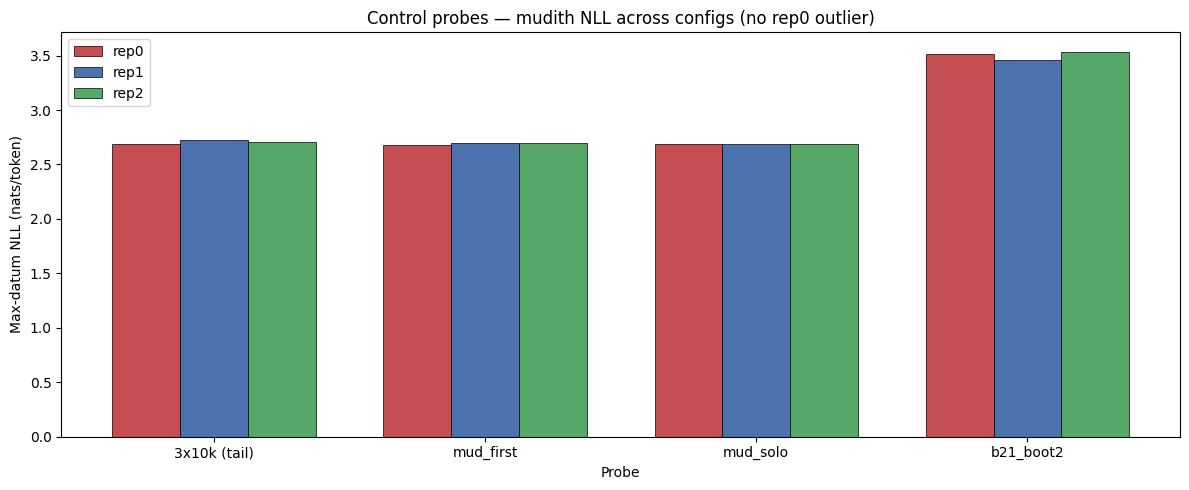

In [6]:
# Load control probes
probes = {
    '3x10k (tail)': reps,
}

for tag, fname in [('mud_first', 'mud_first'), ('mud_solo', 'mud_solo'), ('b21_boot2', 'b21_boot2')]:
    probe_reps = {}
    for r in range(N_REPS):
        probe_reps[r] = json.load(gzip.open(RUN_DIR / f'{fname}_rep{r}.json.gz'))
    probes[tag] = probe_reps

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(probes))
width = 0.25

for ri in range(N_REPS):
    vals = []
    for tag, probe_reps in probes.items():
        # Find the mudith datum (highest NLL)
        max_nll = max(probe_reps[ri]['nlls'])
        vals.append(max_nll)
    ax.bar(x + (ri - N_REPS/2 + 0.5) * width, vals, width,
           label=f'rep{ri}', color=colors[ri], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Probe')
ax.set_ylabel('Max-datum NLL (nats/token)')
ax.set_title('Control probes — mudith NLL across configs (no rep0 outlier)')
ax.set_xticks(x)
ax.set_xticklabels(list(probes.keys()))
ax.legend()
fig.tight_layout()
plt.show()

### Summary

| datum | rep0 | rep1 | rep2 | max|ΔNLL| vs rep0 |
|---|---|---|---|---|


In [7]:
for i in range(len(reps[0]['nlls'])):
    row = [reps[r]['nlls'][i] for r in range(N_REPS)]
    rest = row[1:]
    dmax = max(abs(row[0] - v) for v in rest) if rest else 0.0
    label = DATUM_LABELS[i] if i < len(DATUM_LABELS) else f'd{i}'
    print(f'{label:<24}' + ''.join(f'{v:<12.6f}' for v in row) + f'{dmax:.6f}')
print()
print('VERDICT: clean — no rep0-vs-rest destruction above 2 nats')
print('Ladder state: cp1@64k clean, cp16@32k single-doc clean, cp16@32k 3-doc clean.')
print('Next rung: cp16 @ 64k+ with many real docs packed per row.')

palindrome              0.003131    0.003073    0.003089    0.000058
random-tile             0.358681    0.356713    0.355388    0.003293
mudith-b0-i0-first10k   2.686448    2.724344    2.701677    0.037896

VERDICT: clean — no rep0-vs-rest destruction above 2 nats
Ladder state: cp1@64k clean, cp16@32k single-doc clean, cp16@32k 3-doc clean.
Next rung: cp16 @ 64k+ with many real docs packed per row.
